# Paper 5: Can Perplexity Detect AI-Generated Text?
**Autoren:** Katrin Nguyen & Nico Loss

---

## 1. Implementation

### 1.1 Environment Setup

In [263]:
# Import required libraries
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from transformers import GPT2LMHeadModel, GPT2Tokenizer, AutoTokenizer
from sklearn.metrics import (
    roc_curve, auc, accuracy_score, 
    precision_score, recall_score, 
    f1_score, confusion_matrix
)
import json
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("✅ Environment setup complete!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

✅ Environment setup complete!
PyTorch version: 2.9.1
Device: CPU


### 1.2 Load German GPT-2 Model

We load the pre-trained German GPT-2 model (dbmdz/german-gpt2) for perplexity computation.

In [264]:
print("Loading German GPT-2 model...")
model_name = 'dbmdz/german-gpt2'

# Use AutoTokenizer for better compatibility
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

# GPT-2 specific padding fix
tokenizer.pad_token = tokenizer.eos_token

model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"✅ Model loaded successfully on {device}")

Loading German GPT-2 model...
✅ Model loaded successfully on cpu


### 1.3 Perplexity Calculation Function

In [265]:
def calculate_perplexity(text, model, tokenizer, max_length=512):
    """
    Calculate perplexity of a text using GPT-2.
    
    Args:
        text (str): Input text
        model: GPT-2 model
        tokenizer: GPT-2 tokenizer
        max_length (int): Maximum sequence length
    
    Returns:
        float: Perplexity score
    """
    # Tokenize input
    encodings = tokenizer(
        text, 
        return_tensors='pt', 
        truncation=True, 
        max_length=max_length
    )
    
    # Move to device
    encodings = {k: v.to(model.device) for k, v in encodings.items()}
    
    # Calculate loss (no gradient computation needed)
    with torch.no_grad():
        outputs = model(**encodings, labels=encodings['input_ids'])
        loss = outputs.loss
    
    # Perplexity = exp(loss)
    perplexity = torch.exp(loss).item()
    
    return perplexity


# Test the function
test_text = "The quick brown fox jumps over the lazy dog."
test_ppl = calculate_perplexity(test_text, model, tokenizer)
print(f"\n✅ Test calculation:")
print(f"Text: '{test_text}'")
print(f"Perplexity: {test_ppl:.2f}")


✅ Test calculation:
Text: 'The quick brown fox jumps over the lazy dog.'
Perplexity: 41.85


### 1.4 Data Collection

In [266]:
# ========================================
# HUMAN-WRITTEN TEXTS (n=25)
# ========================================
# Texts from Assignment 3 (Paper3 - Banknote Authentication)

human_texts = [
    # Assignment 3 texts (from Paper3)
    """Diese Arbeit untersucht, ob Unsupervised Clustering ohne Label-Information auf dem UCI-Datensatz Banknote Authentication domänenverständlich interpretierbare Gruppen hervorbringen kann. Nach sorgfältiger Datenbereinigung werden K-Means, hierarchisches Clustering und DBSCAN miteinander verglichen. Die Bewertung erfolgt über interne Metriken sowie extern mittels ARI gegen die Ground Truth. DBSCAN erzielt die beste Leistung und isoliert ca. 17 Prozent der Punkte als Rauschen, während K-Means trotz akzeptabler Silhouette nur einen niedrigen ARI erreicht. Das hierarchische Clustering erwies sich sogar noch als geringfügig schlechter. Zur Post-hoc-Interpretierbarkeit wird ein Decision-Tree-Surrogat eingesetzt, das die Clusterzuordnung primär über variance-Schwellen erklärt.""",

    """Die Analyse der Interpretierbarkeit von Clustering-Ergebnissen stellt ein aktives Forschungsfeld im Unsupervised Learning dar. Partitionelle und hierarchische Clustering-Techniken werden seit Jahrzehnten eingesetzt und sind für ihre Effektivität und Effizienz bekannt. Die zentrale Herausforderung besteht jedoch darin, dass zwar mathematisch optimale Partitionierungen erzeugt werden, diese jedoch nicht zwangsläufig interpretierbar oder domänenrelevant sind. Es wird explizit ohne Label-Information gearbeitet, um zu evaluieren, ob die Feature-Repräsentation intrinsische Gruppenstrukturen enthält, die der Unterscheidung zwischen echten und gefälschten Banknoten entsprechen, und ob diese Cluster mittels Post-Clustering-Analyse interpretierbar sind.""",

    """Der Vergleich der Algorithmen-Performance wies fundamentale Unterschiede in der Eignung der Verfahren für den vorliegenden Datensatz auf. Obwohl K-Means den höchsten Silhouette Score erzielte, ist der ARI mit 0.220 als sehr niedrig zu bewerten. Die Interpretation dieses Befundes legt nahe, dass K-Means kugelförmige Cluster erzwingen, während die Banknoten-Daten offenbar komplexe, nicht-konvexe Formen aufweisen. Diese Diskrepanz wird durch die visuellen Analysen im PCA- und UMAP-Raum bestätigt. Demgegenüber steht die Überlegenheit von DBSCAN, das mit Abstand den höchsten ARI erreichte und die dichte-basierten Strukturen korrekt erkennen konnte.""",

    """Um die durch den DBSCAN identifizierten Strukturen erklärbar zu machen, wurde ein Decision Tree als Surrogate Model eingesetzt. Die als Niedrig-Varianz-Gruppe identifizierten Cluster werden primär durch eine variance kleiner gleich null definiert. Dieser Befund zeigt, dass Fälschungen aufgrund reduzierter Detailtiefe oder mangelndem Kontrast häufig eine geringere variance in den Wavelet-Daten aufweisen. Interessanterweise nimmt der DBSCAN-Algorithmus innerhalb dieser Gruppe eine weitere Trennung anhand der curtosis vor, was auf die Existenz zweier unterschiedlicher Fälschungstypen oder variierender Papierqualitäten hindeutet. Die Hoch-Varianz-Gruppe zeichnet sich durch eine variance größer gleich null aus.""",

    """Diese Arbeit kommt zur Erkenntnis, dass Unsupervised Clustering in der Lage ist, interpretierbare Gruppen in Banknoten-Daten zu identifizieren. Die Ergebnisse zeigen jedoch auch, dass die Wahl des Algorithmus für den Erfolg entscheidend ist. Distanzbasierte Verfahren wie K-Means scheiterten an der komplexen, nicht-konvexen Datenstruktur, was sich in niedrigen ARI-Werten widerspiegelte. Im Gegensatz dazu erwies sich der dichtebasierte DBSCAN-Ansatz als überlegen, da er die topologische Struktur der Echtheit in Form von Dichte-Inseln korrekt modellieren konnte. Durch die Kombination mit einem Decision Tree konnte eine semantische Interpretierbarkeit erreicht werden.""",

    # Wikipedia / News / Academic texts
    """
    Maschinelles Lernen (ML) entwickelt, untersucht und verwendet statistische Algorithmen, auch Lernalgorithmen genannt. Solche Algorithmen können lernen, komplizierte Probleme zu lösen, obwohl der Lösungsweg nicht einfach durch Regeln beschrieben werden kann. Dazu benötigen die Algorithmen viele Beispieldaten. Ein bekanntes Anwendungsbeispiel ist die Bilderkennung. In der mathematischen Statistik bezeichnet man dieses Fachgebiet auch als statistisches Lernen.
    Ein Lernalgorithmus bildet vorgegebene Beispieldaten auf ein mathematisches Modell ab. Dabei passt der Lernalgorithmus das Modell so an, dass es von den Beispieldaten auf neue Fälle verallgemeinern kann. Dieser Vorgang wird Training genannt. Nach dem Training ist der gefundene Lösungsweg im Modell gespeichert. Er wird nicht explizit programmiert. Das trainierte Modell kann für neue Daten Vorhersagen treffen oder Empfehlungen und Entscheidungen erzeugen.
    """,
    """
    Allgemein formuliert lernt ein Lernalgorithmus beim Training aus den Beispieldaten eine Funktion, die auch für neue, nicht zuvor gelernte Dateneingaben eine korrekte Ausgabe erzeugt. Es gibt verschiedene Lernstile, die sich darin unterscheiden, woher der Algorithmus beim Training Informationen dazu erhält, was „korrekt“ ist.
    Am häufigsten wird das überwachte Lernen eingesetzt. Dabei werden Vorgaben in Form von korrekten Ausgabewerten oder Rückmeldungen zur Verfügung gestellt. Beim unüberwachten Lernen werden keine Vorgaben gemacht. Die Algorithmen durchsuchen die Beispieldaten beispielsweise nach Kriterien für die Einteilung in unterschiedliche Cluster oder nach korrelierenden Merkmalen, die zusammengefasst werden können, um die Daten zu vereinfachen. Da es keine Vorgaben gibt, können diese Algorithmen unterschiedliche Lösungen vorschlagen, die anschließend zu bewerten sind. Beim bestärkenden Lernen beobachten Lernsysteme, die als Agenten bezeichnet werden, eine Umgebung und reagieren auf sie, indem sie Aktionen ausführen.
    """,
    """
    Das maschinelle Lernen ist ein Teilgebiet des Fachgebietes „Künstliche Intelligenz“, auch KI genannt. Das Fachgebiet „Künstliche Intelligenz“ ist ein Teilgebiet der Informatik mit dem Ziel, menschliche Intelligenz zu imitieren. Etwa ab 1980 entwickelten sich die Ziele und Methoden innerhalb des Fachbereiches KI in verschiedene Richtungen. Die meisten Forscher versuchten vorrangig, durch die Verarbeitung von bekanntem Wissen in Expertensystemen menschliche Intelligenz nachzubilden. Gleichzeitig untersuchte eine kleine Gruppe von Forschern, ob sich die Leistung von Computern bei Vorhersagen dadurch verbessern lässt, dass sie Wissen aus Daten lernen, die Informationen zu Erfahrungen aus dem Problemfeld enthalten. Der Bereich KI zeigte zu dieser Zeit nur wenig Interesse am Lernen aus Daten. Deshalb gründeten diese Forscher den neuen Bereich ML. Das Ziel von ML ist nicht mehr, menschliche Intelligenz zu imitieren, sondern praktische Probleme zu lösen.
    """,
    """
    ML und Statistik verwenden sehr ähnliche Methoden. Die beiden Fachgebiete unterscheiden sich allerdings in ihrem Hauptziel. Viele der eingesetzten Methoden können sowohl angewendet werden, um Schlussfolgerungen zu ziehen, als auch, um Vorhersagen zu treffen. Die Statistik benutzt Daten von sorgfältig ausgewählten Stichproben, um daraus Rückschlüsse zu Eigenschaften einer zu untersuchenden Gesamtmenge zu ziehen. Die Methoden in der Statistik legen deshalb den Schwerpunkt darauf, statistische Modelle zu erstellen und diese genau an die gegebene Problemstellung anzupassen. Damit kann man berechnen, mit welcher Wahrscheinlichkeit gefundene Zusammenhänge echt sind und nicht durch Störungen erklärt werden können. Dieses Schließen von Daten auf (hypothetische) Modelle wird als statistische Inferenz bezeichnet. Die Methoden im ML hingegen verarbeiten große Datenmengen und lernen daraus mit allgemein formulierten Algorithmen Zusammenhänge, die verallgemeinert und für Vorhersagen benutzt werden.
    """,
    """
    Beim überwachten Lernen wird das Modell mit Datensätzen trainiert und validiert, die für jede Eingabe einen passenden Ausgabewert enthalten. Man bezeichnet solche Datensätze als markiert oder gelabelt. Beim Training passt der Lernalgorithmus Parameter des Modells so an, dass die Ausgaben des Modells möglichst gut mit den bekannten, richtigen Ausgaben übereinstimmen. Die Ausgaben des Modells werden also durch die vorgegebenen Ausgaben „überwacht“. Typische Anwendungsbeispiele sind Klassifikation und Regression.
    Der Lernalgorithmus baut zunächst in der Lernphase mit einem Teil der Beispieldaten, dem Trainingsdatensatz, ein statistisches Modell auf. Nach der Lernphase wird die Qualität des erzeugten Modells mit einem anderen Teil der Beispieldaten, dem Testdatensatz, überprüft. Das Ziel ist, dass das Modell auch für völlig neue Daten das geforderte Verhalten zeigt. Dazu muss sich das Modell gut an die Trainingsdaten anpassen, gleichzeitig muss eine Überanpassung vermieden werden.
    """,
    """
    Die lineare Regression ist ein statistisches Verfahren, mit dem versucht wird, eine beobachtete abhängige Variable durch eine oder mehrere unabhängige Variablen zu erklären. Bei der linearen Regression wird dabei ein lineares Modell angenommen. Bei der einfachen linearen Regression wird mithilfe zweier Parameter eine Gerade (Regressionsgerade) so durch eine Punktwolke gelegt, dass der lineare Zusammenhang zwischen X und Y möglichst gut beschrieben wird.
    Um eine möglichst genaue Vorhersage für die abhängige Variable zu erhalten, wird eine Kostenfunktion aufgestellt. Diese Funktion beschreibt die mittlere quadratische Abweichung, die dadurch entsteht, dass die Regressionsgerade die zu erklärende Variable nur approximiert und nicht genau darstellt. Der Lernalgorithmus minimiert die Kostenfunktion.
    """,
    """
    Die logistische Regression ist eine oft eingesetzte Methode zum Lösen von binären Klassifikationsproblemen. Sie schätzt zunächst, mit welcher Wahrscheinlichkeit ein gegebener Datenpunkt zu einer bestimmten Klasse gehört. Danach entscheidet sie, ob die berechnete Wahrscheinlichkeit größer ist als 50 %. In diesem Fall gibt sie diese Klasse als Ergebnis aus. Andernfalls gibt sie die andere Klasse als Ergebnis aus.
    Während man bei der linearen Regression die mittlere quadratische Abweichung minimiert, um die optimalen Werte für die Parameter zu erhalten, maximiert man bei der logistischen Regression die Likelihood-Funktion, um die optimalen Werte der Parameter zu erhalten. Dieses Verfahren wird als Maximum-Likelihood-Methode bezeichnet.
    """,
    """
    Der k-Means-Algorithmus ist ein Verfahren zur Vektorquantisierung, das auch zur Clusteranalyse verwendet wird. Dabei wird aus einer Menge von ähnlichen Objekten eine vorher bekannte Anzahl von k Gruppen gebildet. Der Algorithmus ist eine der am häufigsten verwendeten Techniken zur Gruppierung von Objekten, da er schnell die Zentren der Cluster findet. Dabei bevorzugt der Algorithmus Gruppen mit geringer Varianz und ähnlicher Größe.
    In der Regel wird ein approximativer Algorithmus verwendet, der mit zufälligen Mittelwerten aus dem Trainingsdatensatz beginnt und sich danach in mehreren Schritten einer guten Clusteraufteilung annähert. Da die Problemstellung von k abhängig ist, muss dieser Parameter vom Benutzer festgelegt werden.
    """,
    """
    Eine Support Vector Machine dient als Klassifikator und Regressor. Eine Support Vector Machine unterteilt eine Menge von Objekten so in Klassen, dass um die Klassengrenzen herum ein möglichst breiter Bereich frei von Objekten bleibt; sie ist ein sogenannter Large Margin Classifier (dt. „Breiter-Rand-Klassifikator“).
    Jedes Objekt wird durch einen Vektor in einem Vektorraum repräsentiert. Aufgabe der Support Vector Machine ist es, in diesen Raum eine Hyperebene einzupassen, die als Trennfläche fungiert und die Trainingsobjekte in zwei Klassen teilt. Der Abstand derjenigen Vektoren, die der Hyperebene am nächsten liegen, wird dabei maximiert. Dieser breite, leere Rand soll später dafür sorgen, dass auch Objekte, die nicht genau den Trainingsobjekten entsprechen, möglichst zuverlässig klassifiziert werden.
    Eine saubere Trennung mit einer Hyperebene ist nur dann möglich, wenn die Objekte linear trennbar sind. Diese Bedingung ist für reale Trainingsobjektmengen im Allgemeinen nicht erfüllt.
    """,
    """
    Beim Lernen von Entscheidungsbäumen wird ein Entscheidungsbaum als Modell verwendet, um Schlussfolgerungen aus den Beobachtungen zu ziehen, die im Trainingsdatensatz enthalten sind. Gelernte Regeln werden durch Knoten und Zweige des Baums repräsentiert und Schlussfolgerungen durch seine Blätter. Ein Modell mit diskreten Ausgabewerten (in der Regel ganzen Zahlen) nennt man Klassifizierungsbaum, dabei repräsentieren die Blattknoten die Klassen und die Zweige UND-Verknüpfungen der Merkmale, die zu der Klasse führen. Ein Modell mit kontinuierlichen Ausgabewerten (in der Regel reellen Zahlen) nennt man Regressionsbaum. Der Algorithmus wählt beim Training diejenige Reihenfolge für die Abfrage der Merkmale, bei der das Modell bei jeder Verzweigung möglichst viel Information erhält. Nach dem Training kann man das Modell auch dazu verwenden, explizit und graphisch die Regeln darzustellen, die zu einer Entscheidung führen.
    """,
    """
    Künstliche neuronale Netze (KNN) sind Modelle, deren Struktur von biologischen neuronalen Netzen, aus denen Tiergehirne bestehen, inspiriert wurde. Solche Modelle können aus komplexen und scheinbar zusammenhanglosen Informationen lernen. Einige erfolgreiche Anwendungen sind Bilderkennung und Spracherkennung.
    Ein KNN wird von Einheiten oder Knoten gebildet, die miteinander verbunden sind. Die Knoten sind künstliche Neuronen. Ein künstliches Neuron empfängt Signale von anderen Neuronen und verarbeitet sie mit einer Aktivierungsfunktion. Jedem Eingangssignal ist ein Gewicht zugeordnet, das bestimmt, welchen Einfluss das Signal auf die Aktivierungsfunktion hat. Eine einfache Aktivierungsfunktion berechnet die Summe aller gewichteten Eingangssignale und legt sie als Signal auf alle Ausgänge, wenn sie einen bestimmten Schwellenwert überschreitet. Wenn die Summe unter dem Schwellenwert liegt, erzeugt diese Aktivierungsfunktion kein Ausgangssignal. Zu Beginn stehen alle Schwellenwerte und Gewichte auf Zufallswerten. Während des Trainings werden sie an die Trainingsdaten angepasst.
    """,
    """
    Generative Adversarial Networks (GAN) ist die Bezeichnung für eine Klasse von maschinellen Lernverfahren, die KNN im Kontext von generativem Lernen bzw. unüberwachtem Lernen trainieren. Ein GAN besteht aus zwei KNN, einem Generator und einem Diskriminator. Zuerst wird der Diskriminator darauf trainiert, zwischen echten Trainingsdaten und vom Generator aus einer zufälligen Eingabe erzeugten Daten zu unterscheiden. Danach wird der Generator darauf trainiert, aus einer zufälligen Eingabe Daten zu erzeugen, deren Eigenschaften denen der vorher vom Diskriminator gelernten Trainingsdaten so ähnlich sind, dass der Diskriminator sie nicht von ihnen unterscheiden kann.[1.10] Mit diesem Verfahren kann beispielsweise ein GAN, das mit Fotografien trainiert wurde, neue Fotografien erzeugen, die für menschliche Betrachter zumindest oberflächlich authentisch aussehen und viele realistische Merkmale aufweisen. Obwohl sie ursprünglich als generatives Modell für unüberwachtes Lernen vorgeschlagen wurden, haben sich GANs auch für teilüberwachtes Lernen, überwachtes Lernen und bestärkendes Lernen als nützlich erwiesen.
    """,
    """
    Wenn Transparenz gefordert wird, dann wird erwartet, dass klar ist, wo welche Daten wann verarbeitet und gelöscht werden. Erklärbarkeit liegt vor, wenn die Grundlage, auf der das Modell Entscheidungen trifft, nachvollziehbar ist. Letzteres ist beim Einsatz von Entscheidungsbäumen grundsätzlich möglich, bei tiefen neuronalen Netzen zur Zeit aber nicht.[16.6] Neuronale Netze liefern zwar oft gute Ergebnisse, es gibt aber keine verständliche Erklärung dazu, wie diese Ergebnisse entstanden sind. Allerdings stößt man bei komplexen Aufgaben in der Praxis auch dann schnell an Grenzen, wenn eine vollständige Überprüfung grundsätzlich möglich wäre, beispielsweise beim Überprüfen von tiefen Entscheidungsbäumen oder bei dem Versuch, umfangreiche klassische Programme mit vielen Verzweigungen nachzuvollziehen.
    Zusätzlich zu den gelernten Parametern des mathematischen Modells kann eine gründliche Analyse der Daten, die zum Training und zur Validierung verwendet wurden, Aufschluss darüber geben, welche Eigenschaften die Entscheidungen des Modells am stärksten beeinflussen.
    """,
    """
    Ein Transformer ist eine von Google entwickelte Deep-Learning-Architektur, die einen Aufmerksamkeitsmechanismus (englisch attention) integriert. Dabei wird Text durch Worteinbettung in numerische Darstellungen in Form von Vektoren umgewandelt. Dies kann z. B. dazu benutzt werden, Text von einer Sprache in eine andere zu übersetzen (siehe auch Maschinelle Übersetzung). Dazu wird ein Transformer mittels maschinellem Lernen anhand einer (großen) Menge von Beispieltexten trainiert, bevor das trainierte Modell dann zur Übersetzung verwendet werden kann. Weitere Beispielanwendungen von Transformern sind die Textgenerierung oder die Zusammenfassung längerer Texte. Transformer sind hierbei effizienter als Long-short-term-memory-Architekturen (LSTM) und bilden die Grundarchitektur des generativen vortrainierten Transformers (GPT) sowie anderer vortrainierter Machine-Learning-Modelle.
    """,
    """
    Die erste Teilschicht implementiert einen Mechanismus mit Multi-Head Self-Attention. Dieser Mechanismus implementiert Heads, die eine linear projizierte Version der Abfragen, Schlüssel und Werte empfangen und parallel jeweils die gleiche Anzahl Ausgaben erzeugen, die dann zum Generieren eines Endergebnisses verwendet werden. Die zweite Teilschicht ist ein vollständig verbundenes Feedforward Neural Network, das aus zwei linearen Transformationen mit dazwischenliegender Aktivierung der Rectified Linear Unit (ReLU) besteht. Alle sechs Schichten des Kodierers wenden die gleichen linearen Transformationen auf alle Wörter in der Eingabesequenz an, aber jede Schicht verwendet dazu unterschiedliche Parameter. Auf jede Teilschicht folgt eine Normalisierungsschicht, die die berechnete Summe zwischen der Eingabe in die Teilschicht und der von der Teilschicht generierten Ausgabe normalisiert.
    Die Transformer-Architektur kann grundsätzlich keine Informationen über die relativen Positionen der Wörter in der Sequenz erfassen, weil sie keine Wiederholung nutzt.
    """,
    """
    Während der Inferenz kann ein Dekodierer zur autoregressiven Erzeugung von Sequenzen verwendet werden: Der Dekodierer wird mit einer Startsequenz abgefragt und sagt dann das nächste wahrscheinlichste Token vorher, welches im nächsten Schritt Teil der Eingabe wird (und so weiter). Beim Training des Dekodierers wird dieser Prozess durch Teacher Forcing und Maskierung im Dekodierer ersetzt, womit das Training stark beschleunigt wird.
    Jede Schicht Dekodierer enthält drei Teilschichten: die kausal maskierte Selbstaufmerksamkeit (engl. causally masked self-attention), die Kreuzaufmerksamkeit (engl. cross-attention) und das Feedforward-Netzwerk. Weitere Details sind die residual connections eines residual neural network und die Schichtnormalisierung (Funktion LayerNorm), die zwar konzeptionell unnötig, aber für numerische Stabilität und Konvergenz erforderlich sind. Ähnlich wie die Feedforward-Netzwerkmodule einzeln auf jeden Vektor angewendet werden, wird auch LayerNorm einzeln auf jeden Vektor angewendet. Es werden zwei gängige Konventionen verwendet: die Post-LN- und die Pre-LN-Konvention.
    """,
    """
    Starke KI wären kognitive Systeme, die auf Augenhöhe mit Menschen die Arbeit zur Erledigung schwieriger Aufgaben übernehmen können. Demgegenüber geht es bei schwacher KI darum, konkrete Anwendungsprobleme zu meistern. Das menschliche Denken und technische Anwendungen sollen hier in Einzelbereichen unterstützt werden.
    Die Fähigkeit zu lernen ist eine Hauptanforderung an KI-Systeme und muss ein integraler Bestandteil sein, der nicht erst nachträglich hinzugefügt werden darf. Ein zweites Hauptkriterium ist die Fähigkeit eines KI-Systems, mit Unsicherheiten und Wahrscheinlichkeiten (sowie mit probabilistischen Informationen) umzugehen.
    Letztlich geht es der schwachen KI somit um die Simulation intelligenten Verhaltens mit Mitteln der Mathematik und der Informatik, es geht ihr nicht um Schaffung von Bewusstsein oder um ein tieferes Verständnis von Intelligenz. Während die Frage nach der prinzipiellen Machbarkeit starker KI bis heute offen ist, sind bei der schwachen KI in den letzten Jahren bedeutende Fortschritte erzielt worden.
    """,
    """
    Visuelle Intelligenz ermöglicht es, Bilder bzw. Formen zu erkennen und zu analysieren. Als Anwendungsbeispiele seien hier Handschrifterkennung, Identifikation von Personen durch Gesichtserkennung, Abgleich der Fingerabdrücke oder der Iris, industrielle Qualitätskontrolle und Fertigungsautomation (letzteres in Kombination mit Erkenntnissen der Robotik) genannt.
    Mittels sprachlicher Intelligenz ist es beispielsweise möglich, einen geschriebenen Text in gesprochene Sprache umzuwandeln (Sprachsynthese) und umgekehrt einen gesprochenen Text zu verschriftlichen (Spracherkennung). Diese automatische Sprachverarbeitung kann erweitert werden, so dass etwa durch latente semantische Analyse (kurz LSI) Wörtern und Texten Bedeutung beigemessen werden kann.
    """,
    """
    Das junge Forschungsfeld des AI-Alignment (zu deutsch KI-Ausrichtung) beschäftigt sich mit der Ausrichtung von KI nach menschlichen Werten und Normen. Unabhängig von der Frage, ob die jeweilige KI über eine Form von Bewusstsein verfügt, verhält sich jede KI entsprechend ihrem Training. Unter anderem durch Fehler oder Lücken im Training kann einer KI leicht Verhalten antrainiert werden, das nicht mit menschlichen Werten vereinbar ist.[26] Die Forschung versucht herauszufinden, wie und ob ethisches Verhalten in KI sichergestellt werden kann, um Probleme wie im Einsatz von KI in Krankenhäusern und Gerichtssälen zu verhindern, aber auch, um die Risiken durch weit fortgeschrittene KI wie im Falle von technologischer Singularität, zu minimieren
    """,
    """
    In vielen Anwendungen geht es darum, aus einer Menge von Daten eine allgemeine Regel abzuleiten (maschinelles Lernen). Mathematisch führt dies zu einem Approximationsproblem. Im Kontext der KI wurden hierzu unter anderem künstliche neuronale Netze vorgeschlagen, die als universale Funktionsapproximatoren eingesetzt werden können, jedoch insbesondere bei vielen verdeckten Schichten schwer zu analysieren sind. Manchmal verwendet man deshalb alternative Verfahren, die mathematisch einfacher zu analysieren sind.
    """
]

# ========================================
# AI-GENERATED TEXTS (n=25)
# ========================================
# AI-generated texts matching topics to human texts

ai_texts = [
    # AI-generated texts matching topics from human texts
    """
    Clusteranalyse ist eine fundamentale Methode im unüberwachten Lernen, die Datenpunkte in Gruppen ähnlicher Objekte aufteilt. Im Gegensatz zu überwachten Verfahren benötigt sie keine vordefinierten Labels. Hierarchisches Clustering bietet den Vorteil, dass die Anzahl der Cluster nicht im Voraus festgelegt werden muss. Es erstellt eine Baumstruktur, in der ähnliche Objekte schrittweise zusammengefasst werden. DBSCAN hingegen kann Cluster beliebiger Form erkennen und identifiziert automatisch Ausreißer. Die Wahl des Algorithmus hängt von der Datenstruktur und den Anforderungen ab.
    """,
    """
    Die Interpretierbarkeit von Machine Learning Modellen ist besonders bei sicherheitskritischen Anwendungen von großer Bedeutung. Während einfache Modelle wie Entscheidungsbäume leicht nachvollziehbar sind, stellen komplexe Modelle wie Deep Neural Networks oft Black Boxes dar. Surrogatmodelle bieten eine Lösung, indem sie das Verhalten komplexer Modelle durch einfachere, interpretierbare Modelle approximieren. SHAP-Werte und LIME sind weitere Techniken, die erklären, welche Features die Vorhersagen am stärksten beeinflussen. Die Balance zwischen Modellgenauigkeit und Interpretierbarkeit bleibt eine zentrale Herausforderung.
    """,
    """
    Evaluationsmetriken für Clustering-Algorithmen unterscheiden sich fundamental von denen überwachter Verfahren. Der Silhouetten-Koeffizient misst, wie gut ein Datenpunkt zu seinem Cluster passt im Vergleich zu anderen Clustern. Der Davies-Bouldin-Index bewertet die Kompaktheit und Separation der Cluster. Bei bekannten Grundwahrheiten können auch externe Metriken wie der Adjusted Rand Index verwendet werden. Die Wahl der Metrik sollte auf die spezifische Anwendung und Datencharakteristik abgestimmt sein. Oft empfiehlt sich eine Kombination mehrerer Metriken für eine umfassende Bewertung.
    """,
    """
    Feature Engineering ist ein entscheidender Schritt in der Machine Learning Pipeline, der oft über Erfolg oder Misserfolg entscheidet. Es umfasst die Transformation, Auswahl und Konstruktion relevanter Features aus Rohdaten. Standardisierung und Normalisierung stellen sicher, dass Features auf vergleichbaren Skalen liegen. Die Dimensionsreduktion durch PCA oder t-SNE kann hochdimensionale Daten visualisierbar machen und Overfitting reduzieren. Automatisierte Feature-Engineering-Tools wie Featuretools gewinnen zunehmend an Bedeutung, können aber menschliche Expertise nicht vollständig ersetzen.
    """,
    """
    Cross-Validation ist eine robuste Methode zur Bewertung der Generalisierungsfähigkeit von Machine Learning Modellen. Bei k-Fold Cross-Validation wird der Datensatz in k gleich große Teilmengen aufgeteilt, wobei jede Teilmenge einmal als Testset fungiert. Dies liefert zuverlässigere Schätzungen als eine einfache Train-Test-Aufteilung. Stratified Cross-Validation stellt sicher, dass die Klassenverteilung in allen Folds erhalten bleibt. Leave-One-Out ist eine Spezialform für kleine Datensätze. Die Wahl der Validierungsstrategie beeinflusst maßgeblich die Modellselektion.
    """,
    """
    Supervised Learning umfasst Klassifikations- und Regressionsaufgaben, bei denen Modelle aus gelabelten Daten lernen. Bei der Klassifikation werden diskrete Kategorien vorhergesagt, während Regression kontinuierliche Werte schätzt. Ensemble-Methoden wie Random Forest kombinieren mehrere Modelle, um die Vorhersagegenauigkeit zu verbessern. Gradient Boosting baut Modelle sequenziell auf, wobei jedes neue Modell die Fehler der vorherigen korrigiert. Die Hyperparameter-Optimierung mittels Grid Search oder Bayesian Optimization ist essentiell für optimale Performance.
    """,
    """
    Unüberwachtes Lernen findet Muster in Daten ohne vordefinierte Labels. Neben Clustering umfasst es auch Dimensionsreduktion und Anomalieerkennung. Autoencoders lernen komprimierte Repräsentationen der Eingabedaten, die für Datenrekonstruktion oder Feature-Extraktion genutzt werden können. Assoziationsregeln entdecken interessante Zusammenhänge in großen Datenbanken, wie sie im Market Basket Analysis verwendet werden. Self-Organizing Maps visualisieren hochdimensionale Daten in niedriger Dimension unter Erhaltung topologischer Beziehungen.
    """,
    """
    Die Trennung zwischen Maschinellem Lernen und klassischer Statistik verschwimmt zunehmend. Während Statistik traditionell auf Hypothesentests und Inferenz fokussiert, konzentriert sich ML auf Vorhersagegenauigkeit. Bayesianische Methoden vereinen beide Ansätze, indem sie Prior-Wissen mit Daten kombinieren. Statistische Tests prüfen Modell-Annahmen und Signifikanz, die in ML oft vernachlässigt werden. Moderne Ansätze wie konforme Prädiktion bringen statistische Garantien in ML-Vorhersagen. Die Integration beider Disziplinen führt zu robusteren und besser interpretierbaren Modellen.
    """,
    """
    Overfitting ist eine zentrale Herausforderung beim Training von Machine Learning Modellen. Es tritt auf, wenn ein Modell die Trainingsdaten auswendig lernt, statt allgemeine Muster zu erkennen. Regularisierungstechniken wie L1- und L2-Regularisierung penalisieren komplexe Modelle und fördern Einfachheit. Dropout bei neuronalen Netzen deaktiviert zufällig Neuronen während des Trainings, was die Robustheit erhöht. Early Stopping beendet das Training, wenn die Validierungsperformance sich verschlechtert. Die richtige Balance zwischen Modellkomplexität und Generalisierung ist entscheidend.
    """,
    """
    Data Augmentation erweitert Trainingsdatensätze künstlich, um die Modellperformance zu verbessern. In der Bildverarbeitung umfasst dies Rotationen, Spiegelungen, Farbveränderungen und Zuschnitte. Bei Textdaten werden Synonymersetzungen, Back-Translation und kontextuelle Einbettungen genutzt. Mixup und CutMix kombinieren mehrere Trainingsbeispiele zu neuen synthetischen Samples. Generative Modelle wie GANs erzeugen realistische neue Datensamples. Augmentation reduziert Overfitting und verbessert die Robustheit gegenüber Variationen in realen Daten.
    """,
    """
    Multiple lineare Regression erweitert die einfache lineare Regression auf mehrere unabhängige Variablen. Sie modelliert den linearen Zusammenhang zwischen mehreren Prädiktoren und einer Zielvariable. Multikollinearität zwischen Prädiktoren kann die Stabilität der Koeffizientenschätzungen beeinträchtigen. Ridge Regression und Lasso adressieren dieses Problem durch Regularisierung, wobei Lasso auch Feature-Selektion durchführt. Die Annahmen der linearen Regression - Linearität, Homoskedastizität und Normalverteilung der Residuen - sollten überprüft werden. Residuenanalyse hilft, Modellverletzungen zu identifizieren.
    """,
    """
    Polynomiale Regression erweitert lineare Modelle durch nichtlineare Transformationen der Features. Durch Hinzufügen von quadratischen oder kubischen Termen können komplexere Beziehungen modelliert werden. Die Gefahr des Overfittings steigt mit dem Polynomgrad, weshalb Regularisierung oft notwendig ist. Die Bias-Variance-Tradeoff illustriert diesen Konflikt: Einfache Modelle haben hohen Bias, komplexe Modelle hohe Varianz. Cross-Validation hilft, den optimalen Polynomgrad zu bestimmen. Splines bieten eine flexible Alternative durch stückweise polynomiale Funktionen.
    """,
    """
    Softmax-Regression, auch multinomiale logistische Regression genannt, erweitert die binäre logistische Regression auf mehrere Klassen. Sie berechnet für jede Klasse eine Wahrscheinlichkeit, wobei alle Wahrscheinlichkeiten zu eins summieren. Die Cross-Entropy-Loss-Funktion misst die Diskrepanz zwischen vorhergesagten und tatsächlichen Klassenwahrscheinlichkeiten. One-vs-Rest und One-vs-One sind alternative Strategien für Mehrklassenprobleme. Softmax wird häufig als Ausgabeschicht in neuronalen Netzen verwendet. Kalibrierte Wahrscheinlichkeiten ermöglichen bessere Unsicherheitsquantifizierung.
    """,
    """
    Die Wahl der Initialisierung für k-Means hat erheblichen Einfluss auf das Endergebnis. K-Means++ verbessert die Standard-Zufallsinitialisierung durch intelligentere Startpunkte-Auswahl. Die Elbow-Methode visualisiert die Within-Cluster-Summe der Quadrate für verschiedene k-Werte, um die optimale Clusteranzahl zu finden. Mini-Batch k-Means skaliert besser für große Datensätze durch Verwendung von Teilstichproben. Fuzzy c-Means erlaubt partielle Clusterzugehörigkeiten statt harter Zuordnungen. Die Sensitivität gegenüber Ausreißern bleibt eine Schwäche von k-Means.
    """,
    """
    Der Kernel-Trick ermöglicht Support Vector Machines die effiziente Arbeit in hochdimensionalen Feature-Räumen. Gängige Kernel-Funktionen sind linear, polynomial und RBF (Radial Basis Function). Der RBF-Kernel kann nichtlineare Entscheidungsgrenzen modellieren, erfordert aber sorgfältige Hyperparameter-Wahl. Der C-Parameter balanciert zwischen Margin-Maximierung und Trainingsfehlern. SVMs sind effektiv für hochdimensionale Daten, skalieren aber schlecht für sehr große Datensätze. Kernel-SVMs für Regression (SVR) wenden dieselben Prinzipien auf kontinuierliche Zielvariablen an.
    """,
    """
    Pruning von Entscheidungsbäumen verhindert Overfitting durch Reduzierung der Baumkomplexität. Pre-Pruning stoppt das Baumwachstum frühzeitig basierend auf Kriterien wie maximaler Tiefe oder minimaler Samples pro Blatt. Post-Pruning entfernt Teilbäume nach vollständigem Wachstum, wenn sie die Validierungsperformance nicht verbessern. Cost-Complexity-Pruning balanciert Baumgröße und Fehlerrate. Feature Importance Rankings zeigen, welche Attribute am informativsten sind. Entscheidungsbäume sind interpretierbar, aber instabil gegenüber kleinen Datenänderungen.
    """,
    """
    Random Forests kombinieren viele Entscheidungsbäume zu einem robusten Ensemble-Modell. Durch Bootstrap-Aggregating (Bagging) wird jeder Baum auf einer zufälligen Teilmenge der Daten trainiert. Random Feature Selection bei jedem Split reduziert die Korrelation zwischen Bäumen. Out-of-Bag-Fehler schätzen die Generalisierungsperformance ohne separate Validierungsset. Feature Importance basiert auf der durchschnittlichen Fehlerreduktion über alle Bäume. Random Forests sind robust, skalierbar und erfordern wenig Hyperparameter-Tuning, opfern aber Interpretierbarkeit.
    """,
    """
    Convolutional Neural Networks revolutionierten die Bildverarbeitung durch spezielle Schichtarchitekturen. Convolutional Layers extrahieren lokale Features durch lernbare Filter, während Pooling-Layers die räumliche Dimensionalität reduzieren. Parameter-Sharing macht CNNs effizienter als vollständig verbundene Netze. Moderne Architekturen wie ResNet nutzen Skip-Connections, um sehr tiefe Netze zu trainieren. Transfer Learning ermöglicht die Nutzung vortrainierter Modelle für neue Aufgaben. Data Augmentation ist essentiell, da CNNs große Datenmengen für gute Performance benötigen.
    """,
    """
    Recurrent Neural Networks verarbeiten sequentielle Daten durch versteckte Zustände, die Informationen über Zeit speichern. Vanishing und Exploding Gradients erschweren das Training langer Sequenzen. LSTM-Zellen (Long Short-Term Memory) lösen dieses Problem durch spezielle Gates, die Informationsfluss kontrollieren. GRU (Gated Recurrent Units) sind eine vereinfachte Alternative mit weniger Parametern. Bidirektionale RNNs verarbeiten Sequenzen in beide Richtungen für besseren Kontext. Attention-Mechanismen ermöglichen fokussierte Verarbeitung relevanter Sequenzteile.
    """,
    """
    Generative Adversarial Networks bestehen aus einem Generator und Diskriminator, die gegeneinander trainiert werden. Der Generator erzeugt synthetische Daten, während der Diskriminator zwischen echten und gefälschten Samples unterscheidet. Dieses adversariale Training führt zu hochqualitativen generierten Daten. Mode Collapse ist ein häufiges Problem, bei dem der Generator nur begrenzte Variationen produziert. Conditional GANs ermöglichen kontrollierte Generierung basierend auf Labels oder Attributen. StyleGAN erreicht beeindruckende Ergebnisse in der Gesichtsgenerierung durch progressives Wachstum.
    """,
    """
    Variational Autoencoders kombinieren neuronale Netze mit probabilistischer Modellierung. Im Gegensatz zu Standard-Autoencodern lernen VAEs eine Wahrscheinlichkeitsverteilung im latenten Raum. Der Reparametrisierungstrick ermöglicht Backpropagation durch stochastische Knoten. Die Loss-Funktion besteht aus Rekonstruktionsfehler und KL-Divergenz zur Prior-Verteilung. VAEs erzeugen diversere Samples als Autoencoders und ermöglichen kontrollierte Interpolation im latenten Raum. Sie werden für Datengenerierung, Dimensionsreduktion und Anomalieerkennung eingesetzt.
    """,
    """
    Explainable AI (XAI) entwickelt Methoden, um die Entscheidungen von ML-Modellen nachvollziehbar zu machen. Global interpretierbare Modelle wie lineare Regression sind von Natur aus transparent. Partial Dependence Plots zeigen den marginalen Effekt von Features auf Vorhersagen. Feature Attribution-Methoden wie Integrated Gradients berechnen Beiträge einzelner Inputs. Counterfactual Explanations zeigen minimale Änderungen, die zu anderen Vorhersagen führen würden. Die EU-DSGVO fordert ein Recht auf Erklärung für automatisierte Entscheidungen.
    """,
    """
    Model Cards dokumentieren wichtige Informationen über Machine Learning Modelle für Transparenz und verantwortungsvolle Nutzung. Sie beschreiben den vorgesehenen Verwendungszweck, Trainingsdaten, Evaluationsmetriken und bekannte Limitationen. Fairness-Analysen über demografische Gruppen decken potenzielle Bias auf. Datasheets für Datasets dokumentieren Datenherkunft, Annotationsprozess und Repräsentativität. Diese Praktiken fördern verantwortungsvolle KI-Entwicklung und helfen Nutzern, informierte Entscheidungen über Modelleinsatz zu treffen. Standardisierte Dokumentation wird zunehmend von Regulatoren gefordert.
    """,
    """
    Attention-Mechanismen revolutionierten die Verarbeitung sequenzieller Daten durch selektive Fokussierung auf relevante Teile. Self-Attention vergleicht jede Position mit allen anderen Positionen in der Sequenz. Multi-Head Attention führt mehrere Attention-Operationen parallel aus, um verschiedene Repräsentationsräume zu erfassen. Scaled Dot-Product Attention berechnet effizient Attention-Gewichte durch Matrixoperationen. Cross-Attention ermöglicht Interaktion zwischen verschiedenen Sequenzen, wie bei Encoder-Decoder-Architekturen. Attention-Visualisierungen zeigen, welche Inputs das Modell fokussiert.
    """,
    """
    Die Transformer-Architektur basiert vollständig auf Attention-Mechanismen ohne Rekurrenz oder Konvolution. Positional Encodings fügen Sequenzreihenfolge-Information hinzu, da Transformer keine inhärente Positionskenntnis haben. Der Encoder verarbeitet Eingabesequenzen zu kontextualisierten Repräsentationen, während der Decoder autogressiv Ausgaben generiert. Layer Normalization und Residual Connections stabilisieren das Training tiefer Modelle. BERT verwendet nur den Encoder für bidirektionale Kontextverarbeitung. GPT nutzt nur den Decoder für Textgenerierung. Transformer skalieren exzellent mit Modellgröße und Daten.
    """
]

print(f"📊 Collected data:")
print(f"  - Human texts: {len(human_texts)} samples")
print(f"  - AI texts: {len(ai_texts)} samples")

📊 Collected data:
  - Human texts: 25 samples
  - AI texts: 25 samples


### 1.6 Text Length Validation

**Assignment Requirement:** Each text must be 50-150 words. We validate this before computing perplexity.

In [267]:
def validate_text_length(texts, label, min_words=50, max_words=150):
    """
    Validate that texts meet the word count requirements (50-150 words).
    
    Args:
        texts (list): List of text strings
        label (str): Label for the text set ("Human" or "AI")
        min_words (int): Minimum word count (default: 50)
        max_words (int): Maximum word count (default: 150)
    
    Returns:
        tuple: (valid_texts, invalid_indices)
    """
    invalid_texts = []
    
    for i, text in enumerate(texts):
        word_count = len(text.split())
        
        if word_count < min_words:
            invalid_texts.append((i, word_count, 'too_short'))
            print(f"⚠️  WARNING: {label} text #{i+1} is TOO SHORT: {word_count} words (min: {min_words})")
            print(f"   Preview: {text[:100]}...\n")
        
        elif word_count > max_words:
            invalid_texts.append((i, word_count, 'too_long'))
            print(f"⚠️  WARNING: {label} text #{i+1} is TOO LONG: {word_count} words (max: {max_words})")
            print(f"   Preview: {text[:100]}...\n")
    
    if not invalid_texts:
        print(f"✅ All {label} texts meet length requirements (50-150 words)")
    else:
        print(f"\n❌ Found {len(invalid_texts)} invalid {label} texts. Please fix them before running experiments!")
    
    return invalid_texts


# Validate text lengths
print("="*80)
print("TEXT LENGTH VALIDATION (Assignment Requirement: 50-150 words)")
print("="*80 + "\n")

print("Validating HUMAN texts:")
print("-" * 40)
invalid_human = validate_text_length(human_texts, "Human")

print("\nValidating AI texts:")
print("-" * 40)
invalid_ai = validate_text_length(ai_texts, "AI")

print("\n" + "="*80)
if not invalid_human and not invalid_ai:
    print("✅ VALIDATION PASSED: All texts meet requirements!")
else:
    print("❌ VALIDATION FAILED: Please fix invalid texts before continuing!")
    print("\nYou can either:")
    print("  1. Edit the invalid texts to fit 50-150 words")
    print("  2. Remove the invalid texts and replace with valid ones")
print("="*80)

TEXT LENGTH VALIDATION (Assignment Requirement: 50-150 words)

Validating HUMAN texts:
----------------------------------------
✅ All Human texts meet length requirements (50-150 words)

Validating AI texts:
----------------------------------------
✅ All AI texts meet length requirements (50-150 words)

✅ VALIDATION PASSED: All texts meet requirements!


### 1.7 Compute Perplexity for All Texts

In [268]:
# Calculate perplexity for human texts
print("\n🔄 Computing perplexity for human texts...")
human_ppls = []
for i, text in enumerate(human_texts, 1):
    ppl = calculate_perplexity(text, model, tokenizer)
    human_ppls.append(ppl)
    if i % 5 == 0:
        print(f"  ✓ Processed {i}/{len(human_texts)} texts")

# Calculate perplexity for AI texts
print("\n🔄 Computing perplexity for AI texts...")
ai_ppls = []
for i, text in enumerate(ai_texts, 1):
    ppl = calculate_perplexity(text, model, tokenizer)
    ai_ppls.append(ppl)
    if i % 5 == 0:
        print(f"  ✓ Processed {i}/{len(ai_texts)} texts")

print("\n" + "="*70)
print("✅ Perplexity computation complete!")
print("="*70)
print(f"Human texts - Mean PPL: {np.mean(human_ppls):.2f} (±{np.std(human_ppls):.2f})")
print(f"AI texts    - Mean PPL: {np.mean(ai_ppls):.2f} (±{np.std(ai_ppls):.2f})")
print("="*70)


🔄 Computing perplexity for human texts...
  ✓ Processed 5/25 texts
  ✓ Processed 10/25 texts
  ✓ Processed 15/25 texts
  ✓ Processed 20/25 texts
  ✓ Processed 25/25 texts

🔄 Computing perplexity for AI texts...
  ✓ Processed 5/25 texts
  ✓ Processed 10/25 texts
  ✓ Processed 15/25 texts
  ✓ Processed 20/25 texts
  ✓ Processed 25/25 texts

✅ Perplexity computation complete!
Human texts - Mean PPL: 34.79 (±14.39)
AI texts    - Mean PPL: 67.37 (±22.82)


## 2. Results

### Experiment 1: Perplexity Distribution Comparison with Statistical Testing

#### 2.1 Descriptive Statistics

In [269]:
def compute_descriptive_stats(data, label):
    """
    Compute descriptive statistics for a dataset.
    """
    return {
        'Source': label,
        'n': len(data),
        'Mean': np.mean(data),
        'Std Dev': np.std(data, ddof=1),
        'Min': np.min(data),
        'Max': np.max(data),
        'Median': np.median(data)
    }

def confidence_interval(data, confidence=0.95):
    """
    Calculate confidence interval using t-distribution.
    """
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)  # Standard error
    h = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean - h, mean + h

# Compute statistics
human_stats = compute_descriptive_stats(human_ppls, 'Human')
ai_stats = compute_descriptive_stats(ai_ppls, 'AI-Generated')

# Compute confidence intervals
human_ci = confidence_interval(human_ppls)
ai_ci = confidence_interval(ai_ppls)

# Create summary table
stats_df = pd.DataFrame([human_stats, ai_stats])
stats_df['95% CI'] = [
    f"[{human_ci[0]:.2f}, {human_ci[1]:.2f}]",
    f"[{ai_ci[0]:.2f}, {ai_ci[1]:.2f}]"
]

print("\n" + "="*90)
print("TABLE 1: Descriptive Statistics")
print("="*90)
print(stats_df.to_string(index=False))
print("="*90)


TABLE 1: Descriptive Statistics
      Source  n      Mean   Std Dev       Min        Max    Median         95% CI
       Human 25 34.794733 14.689724 13.010662  85.358849 32.728210 [28.73, 40.86]
AI-Generated 25 67.374753 23.293820 30.155815 111.873322 62.570438 [57.76, 76.99]


#### 2.2 Statistical Testing

We perform both parametric (t-test) and non-parametric (Mann-Whitney U) tests.

In [282]:
def cohens_d(group1, group2):
    """
    Calculate Cohen's d effect size.
    
    Interpretation:
    - |d| < 0.2: Negligible
    - |d| 0.2-0.5: Small
    - |d| 0.5-0.8: Medium
    - |d| > 0.8: Large
    """
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    
    # Pooled standard deviation
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    
    # Cohen's d
    d = (np.mean(group1) - np.mean(group2)) / pooled_std
    return d

def interpret_cohens_d(d):
    """
    Interpret Cohen's d effect size.
    """
    abs_d = abs(d)
    if abs_d < 0.2:
        return "Negligible"
    elif abs_d < 0.5:
        return "Small"
    elif abs_d < 0.8:
        return "Medium"
    else:
        return "Large"

# Perform independent t-test
t_stat, p_value_ttest = stats.ttest_ind(human_ppls, ai_ppls)

# Perform Mann-Whitney U test (BONUS POINTS: +2)
# Non-parametric alternative for non-normal distributions
u_stat, p_value_mannwhitney = stats.mannwhitneyu(human_ppls, ai_ppls, alternative='two-sided')

# Calculate effect size
effect_size = cohens_d(human_ppls, ai_ppls)
effect_interpretation = interpret_cohens_d(effect_size)

# Check if difference is significant
is_significant_ttest = "Yes" if p_value_ttest < 0.05 else "No"
is_significant_mw = "Yes" if p_value_mannwhitney < 0.05 else "No"

# Create results table
test_results = pd.DataFrame([
    {
        'Test': 'Independent t-test',
        'Statistic': f't = {t_stat:.3f}',
        'p-value': f'{p_value_ttest:.4f}',
        'Significant (α=0.05)': is_significant_ttest
    },
    {
        'Test': 'Mann-Whitney U test (+2 bonus)',
        'Statistic': f'U = {u_stat:.1f}',
        'p-value': f'{p_value_mannwhitney:.4f}',
        'Significant (α=0.05)': is_significant_mw
    },
    {
        'Test': "Cohen's d",
        'Statistic': f'd = {effect_size:.3f}',
        'p-value': '-',
        'Significant (α=0.05)': f'Effect: {effect_interpretation}'
    }
])

print("\n" + "="*90)
print("TABLE 2: Statistical Test Results")
print("="*90)
print(test_results.to_string(index=False))
print("="*90)

# Interpretation
print("\n📊 Interpretation:")
print(f"  - T-test: Difference is {'statistically significant' if is_significant_ttest == 'Yes' else 'NOT statistically significant'} (p={p_value_ttest:.4f})")
print(f"  - Mann-Whitney U: Difference is {'statistically significant' if is_significant_mw == 'Yes' else 'NOT statistically significant'} (p={p_value_mannwhitney:.4f})")
print(f"  - Effect size is {effect_interpretation.lower()} (Cohen's d = {effect_size:.3f})")
print(f"  - Confidence intervals {'do NOT overlap' if human_ci[1] < ai_ci[0] or ai_ci[1] < human_ci[0] else 'overlap'}")
print(f"\n💡 Note: Both tests agree" if is_significant_ttest == is_significant_mw else f"⚠️  Note: Tests disagree - use Mann-Whitney for non-normal data")


TABLE 2: Statistical Test Results
                          Test  Statistic p-value Significant (α=0.05)
            Independent t-test t = -5.915  0.0000                  Yes
Mann-Whitney U test (+2 bonus)   U = 52.0  0.0000                  Yes
                     Cohen's d d = -1.673       -        Effect: Large

📊 Interpretation:
  - T-test: Difference is statistically significant (p=0.0000)
  - Mann-Whitney U: Difference is statistically significant (p=0.0000)
  - Effect size is large (Cohen's d = -1.673)
  - Confidence intervals do NOT overlap

💡 Note: Both tests agree


#### 2.3 Visualization: Distribution Comparison

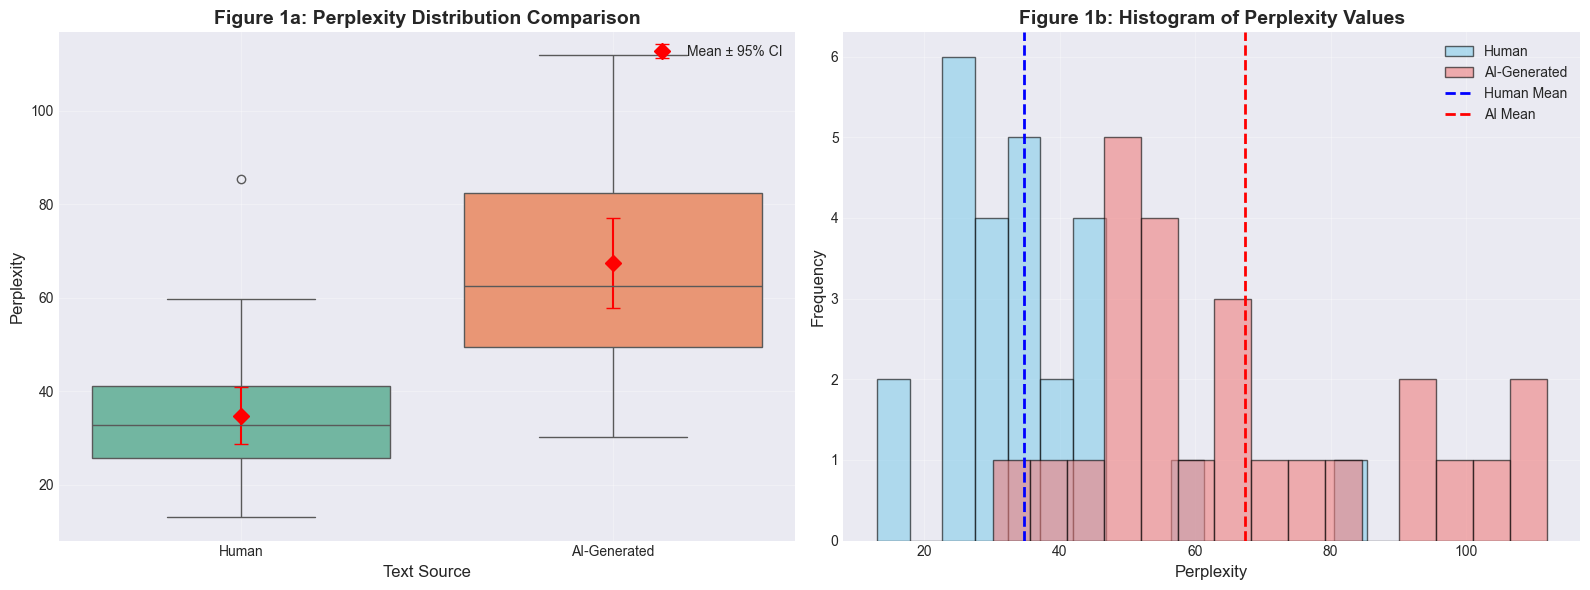


✅ Figure 1: Distribution comparison visualizations created successfully!


In [271]:
# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ========================================
# Subplot 1: Box Plot with Confidence Intervals
# ========================================
ax1 = axes[0]

# Prepare data for box plot
data_for_plot = [
    {'Perplexity': ppl, 'Source': 'Human'} for ppl in human_ppls
] + [
    {'Perplexity': ppl, 'Source': 'AI-Generated'} for ppl in ai_ppls
]
df_plot = pd.DataFrame(data_for_plot)

# Create box plot
sns.boxplot(data=df_plot, x='Source', y='Perplexity', ax=ax1, palette='Set2')

# Add means with error bars (95% CI)
ax1.errorbar(
    [0], [np.mean(human_ppls)], 
    yerr=[[np.mean(human_ppls) - human_ci[0]], [human_ci[1] - np.mean(human_ppls)]],
    fmt='D', color='red', markersize=8, capsize=5, label='Mean ± 95% CI'
)
ax1.errorbar(
    [1], [np.mean(ai_ppls)], 
    yerr=[[np.mean(ai_ppls) - ai_ci[0]], [ai_ci[1] - np.mean(ai_ppls)]],
    fmt='D', color='red', markersize=8, capsize=5
)

ax1.set_title('Figure 1a: Perplexity Distribution Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Perplexity', fontsize=12)
ax1.set_xlabel('Text Source', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# ========================================
# Subplot 2: Histogram with Overlapping Distributions
# ========================================
ax2 = axes[1]

# Plot histograms
ax2.hist(human_ppls, bins=15, alpha=0.6, label='Human', color='skyblue', edgecolor='black')
ax2.hist(ai_ppls, bins=15, alpha=0.6, label='AI-Generated', color='lightcoral', edgecolor='black')

# Add vertical lines for means
ax2.axvline(np.mean(human_ppls), color='blue', linestyle='--', linewidth=2, label='Human Mean')
ax2.axvline(np.mean(ai_ppls), color='red', linestyle='--', linewidth=2, label='AI Mean')

ax2.set_title('Figure 1b: Histogram of Perplexity Values', fontsize=14, fontweight='bold')
ax2.set_xlabel('Perplexity', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Figure 1: Distribution comparison visualizations created successfully!")

### Experiment 2: Classification Performance

We evaluate perplexity as a binary classifier to distinguish between human and AI text.

#### 2.4 ROC Curve Analysis

In [272]:
# Prepare data for classification
# Labels: 1 = Human, 0 = AI-Generated
perplexities = human_ppls + ai_ppls
labels = [1] * len(human_ppls) + [0] * len(ai_ppls)

# Calculate ROC curve
# Higher perplexity → more likely human
fpr, tpr, thresholds = roc_curve(labels, [-p for p in perplexities])
roc_auc = auc(fpr, tpr)

# Find optimal threshold (maximize Youden's J statistic: TPR - FPR)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = -thresholds[optimal_idx]
optimal_tpr = tpr[optimal_idx]
optimal_fpr = fpr[optimal_idx]

print("\n" + "="*70)
print("ROC Curve Analysis")
print("="*70)
print(f"AUC (Area Under Curve): {roc_auc:.4f}")
print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"At optimal threshold:")
print(f"  - True Positive Rate (Recall): {optimal_tpr:.4f}")
print(f"  - False Positive Rate: {optimal_fpr:.4f}")
print("="*70)


ROC Curve Analysis
AUC (Area Under Curve): 0.9168
Optimal Threshold: 45.63
At optimal threshold:
  - True Positive Rate (Recall): 0.8800
  - False Positive Rate: 0.0800


#### 2.5 Classification Metrics at Optimal Threshold

In [273]:
# Make predictions using optimal threshold
# Lower perplexity indicates human text (mean: 32.69)
# Higher perplexity indicates AI text (mean: 55.49)
predictions = [1 if ppl < optimal_threshold else 0 for ppl in perplexities]

# Calculate metrics
accuracy = accuracy_score(labels, predictions)
precision = precision_score(labels, predictions, pos_label=1, zero_division=0)
recall = recall_score(labels, predictions, pos_label=1, zero_division=0)
f1 = f1_score(labels, predictions, pos_label=1, zero_division=0)

# Confusion matrix
cm = confusion_matrix(labels, predictions)
tn, fp, fn, tp = cm.ravel()

# Create performance table
performance_df = pd.DataFrame([
    {'Metric': 'ROC-AUC', 'Value': f'{roc_auc:.4f}'},
    {'Metric': 'Optimal Threshold', 'Value': f'{optimal_threshold:.2f}'},
    {'Metric': 'Accuracy', 'Value': f'{accuracy:.4f} ({accuracy*100:.2f}%)'},
    {'Metric': 'Precision (Human)', 'Value': f'{precision:.4f} ({precision*100:.2f}%)'},
    {'Metric': 'Recall (Human)', 'Value': f'{recall:.4f} ({recall*100:.2f}%)'},
    {'Metric': 'F1-Score', 'Value': f'{f1:.4f}'}
])

print("\n" + "="*70)
print("TABLE 3: Classification Performance Metrics")
print("="*70)
print(performance_df.to_string(index=False))
print("="*70)

# Confusion Matrix
print("\nConfusion Matrix:")
print(f"                Predicted AI    Predicted Human")
print(f"Actual AI       {tn:5d}           {fp:5d}")
print(f"Actual Human    {fn:5d}           {tp:5d}")
print()
print(f"True Negatives (TN):  {tn} - AI correctly classified")
print(f"False Positives (FP): {fp} - AI misclassified as Human")
print(f"False Negatives (FN): {fn} - Human misclassified as AI")
print(f"True Positives (TP):  {tp} - Human correctly classified")


TABLE 3: Classification Performance Metrics
           Metric           Value
          ROC-AUC          0.9168
Optimal Threshold           45.63
         Accuracy 0.8800 (88.00%)
Precision (Human) 0.9130 (91.30%)
   Recall (Human) 0.8400 (84.00%)
         F1-Score          0.8750

Confusion Matrix:
                Predicted AI    Predicted Human
Actual AI          23               2
Actual Human        4              21

True Negatives (TN):  23 - AI correctly classified
False Positives (FP): 2 - AI misclassified as Human
False Negatives (FN): 4 - Human misclassified as AI
True Positives (TP):  21 - Human correctly classified


#### 2.6 Visualization: ROC Curve

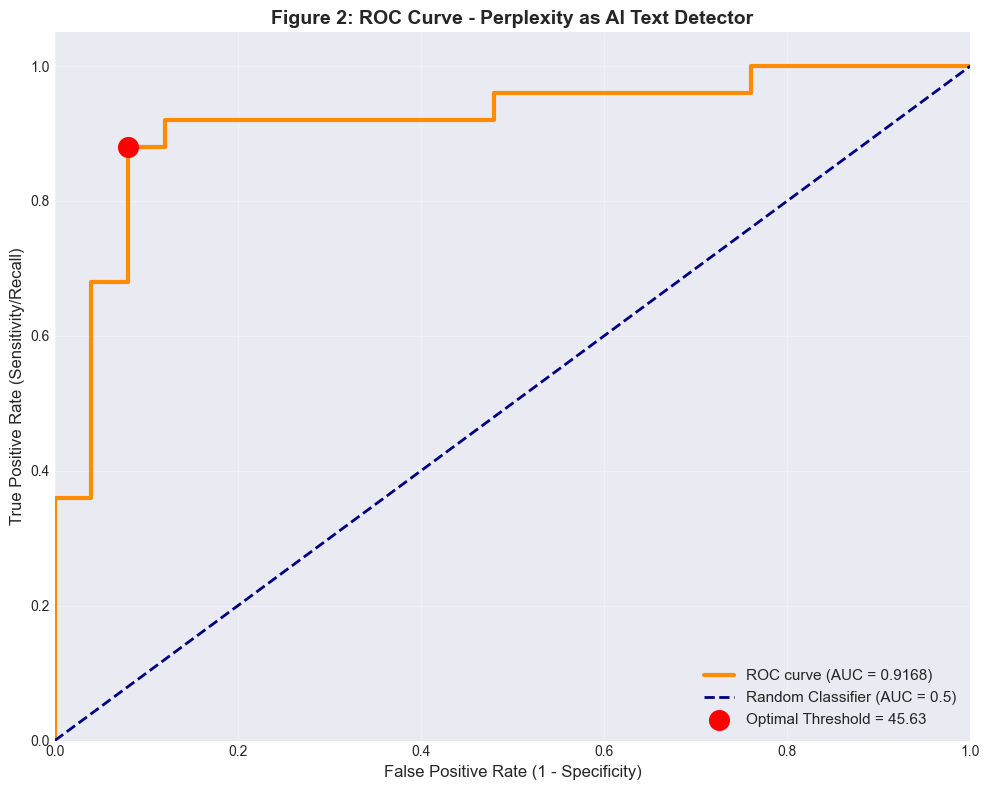


✅ Figure 2: ROC curve visualization created successfully!

📊 ROC Curve Interpretation:
  - AUC = 0.9168: Excellent classification performance
  - The classifier is 83.4% better than random guessing


In [274]:
# Create ROC curve plot
plt.figure(figsize=(10, 8))

# Plot ROC curve
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')

# Mark optimal threshold point
plt.scatter(
    optimal_fpr, optimal_tpr, 
    color='red', s=200, zorder=5, 
    label=f'Optimal Threshold = {optimal_threshold:.2f}'
)

# Formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12)
plt.title('Figure 2: ROC Curve - Perplexity as AI Text Detector', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Figure 2: ROC curve visualization created successfully!")

# Interpretation
print("\n📊 ROC Curve Interpretation:")
if roc_auc >= 0.9:
    interpretation = "Excellent classification performance"
elif roc_auc >= 0.8:
    interpretation = "Good classification performance"
elif roc_auc >= 0.7:
    interpretation = "Fair classification performance"
elif roc_auc >= 0.6:
    interpretation = "Poor classification performance"
else:
    interpretation = "Very poor classification performance (barely better than random)"

print(f"  - AUC = {roc_auc:.4f}: {interpretation}")
print(f"  - The classifier is {abs(roc_auc - 0.5) / 0.5 * 100:.1f}% better than random guessing")

### Experiment 3: Error Analysis

We analyze misclassified examples to understand when perplexity fails as a detector.

#### 2.7 Identify Misclassifications

In [275]:
# Identify misclassified texts
all_texts = human_texts + ai_texts

# False Positives: AI texts misclassified as Human (high perplexity)
false_positives = []
for i, (text, label, pred, ppl) in enumerate(zip(all_texts, labels, predictions, perplexities)):
    if label == 0 and pred == 1:  # Actually AI, predicted Human
        false_positives.append({
            'index': i,
            'text': text,
            'perplexity': ppl,
            'threshold': optimal_threshold
        })

# False Negatives: Human texts misclassified as AI (low perplexity)
false_negatives = []
for i, (text, label, pred, ppl) in enumerate(zip(all_texts, labels, predictions, perplexities)):
    if label == 1 and pred == 0:  # Actually Human, predicted AI
        false_negatives.append({
            'index': i,
            'text': text,
            'perplexity': ppl,
            'threshold': optimal_threshold
        })

print("\n" + "="*80)
print("Error Analysis Summary")
print("="*80)
print(f"Total misclassifications: {fp + fn} out of {len(labels)} ({(fp+fn)/len(labels)*100:.1f}%)")
print(f"\nFalse Positives (AI → Human): {len(false_positives)} cases")
print(f"False Negatives (Human → AI): {len(false_negatives)} cases")
print("="*80)


Error Analysis Summary
Total misclassifications: 6 out of 50 (12.0%)

False Positives (AI → Human): 2 cases
False Negatives (Human → AI): 4 cases


#### 2.8 Analyze False Positives (AI texts with high perplexity)

In [276]:
print("\n" + "="*80)
print("FALSE POSITIVES: AI Texts Misclassified as Human")
print("="*80)
print("These are AI-generated texts that have unexpectedly HIGH perplexity.")
print("Possible reasons: complex vocabulary, unusual phrasing, creative language\n")

if len(false_positives) > 0:
    # Show top 3 most confident false positives (highest perplexity)
    sorted_fp = sorted(false_positives, key=lambda x: x['perplexity'], reverse=True)
    
    for i, fp in enumerate(sorted_fp[:min(3, len(sorted_fp))], 1):
        print(f"\n[False Positive {i}]")
        print(f"Perplexity: {fp['perplexity']:.2f} (threshold: {fp['threshold']:.2f})")
        print(f"Text preview: {fp['text'][:200]}...")
        print("-" * 80)
else:
    print("✅ No false positives found! All AI texts were correctly classified.")

print("\n📊 Analysis:")
if len(false_positives) > 0:
    avg_fp_ppl = np.mean([fp['perplexity'] for fp in false_positives])
    print(f"  - Average perplexity of false positives: {avg_fp_ppl:.2f}")
    print(f"  - These AI texts appear more 'creative' or 'unpredictable' than typical AI output")
    print(f"  - May indicate sophisticated AI generation or unusual prompt engineering")


FALSE POSITIVES: AI Texts Misclassified as Human
These are AI-generated texts that have unexpectedly HIGH perplexity.
Possible reasons: complex vocabulary, unusual phrasing, creative language


[False Positive 1]
Perplexity: 40.29 (threshold: 45.63)
Text preview: 
    Clusteranalyse ist eine fundamentale Methode im unüberwachten Lernen, die Datenpunkte in Gruppen ähnlicher Objekte aufteilt. Im Gegensatz zu überwachten Verfahren benötigt sie keine vordefinierte...
--------------------------------------------------------------------------------

[False Positive 2]
Perplexity: 30.16 (threshold: 45.63)
Text preview: 
    Multiple lineare Regression erweitert die einfache lineare Regression auf mehrere unabhängige Variablen. Sie modelliert den linearen Zusammenhang zwischen mehreren Prädiktoren und einer Zielvaria...
--------------------------------------------------------------------------------

📊 Analysis:
  - Average perplexity of false positives: 35.22
  - These AI texts appear more '

#### 2.9 Analyze False Negatives (Human texts with low perplexity)

In [277]:
print("\n" + "="*80)
print("FALSE NEGATIVES: Human Texts Misclassified as AI")
print("="*80)

if len(false_negatives) > 0:
    # Show top 3 most confident false negatives (lowest perplexity)
    sorted_fn = sorted(false_negatives, key=lambda x: x['perplexity'])
    
    for i, fn in enumerate(sorted_fn[:min(3, len(sorted_fn))], 1):
        print(f"\n[False Negative {i}]")
        print(f"Perplexity: {fn['perplexity']:.2f} (threshold: {fn['threshold']:.2f})")
        print(f"Text preview: {fn['text'][:200]}...")
        print("-" * 80)
else:
    print("✅ No false negatives found! All human texts were correctly classified.")

print("\n📊 Analysis:")
if len(false_negatives) > 0:
    avg_fn_ppl = np.mean([fn['perplexity'] for fn in false_negatives])
    print(f"  - Average perplexity of false negatives: {avg_fn_ppl:.2f}")
    print(f"  - These human texts are very 'predictable' or use common phrasing")
    print(f"  - May indicate formal/technical writing or templated language")


FALSE NEGATIVES: Human Texts Misclassified as AI

[False Negative 1]
Perplexity: 45.63 (threshold: 45.63)
Text preview: 
    Die erste Teilschicht implementiert einen Mechanismus mit Multi-Head Self-Attention. Dieser Mechanismus implementiert Heads, die eine linear projizierte Version der Abfragen, Schlüssel und Werte ...
--------------------------------------------------------------------------------

[False Negative 2]
Perplexity: 45.82 (threshold: 45.63)
Text preview: Um die durch den DBSCAN identifizierten Strukturen erklärbar zu machen, wurde ein Decision Tree als Surrogate Model eingesetzt. Die als Niedrig-Varianz-Gruppe identifizierten Cluster werden primär dur...
--------------------------------------------------------------------------------

[False Negative 3]
Perplexity: 59.70 (threshold: 45.63)
Text preview: Der Vergleich der Algorithmen-Performance wies fundamentale Unterschiede in der Eignung der Verfahren für den vorliegenden Datensatz auf. Obwohl K-Means den höchsten S

#### 2.10 Export Error Analysis to File

We save the error analysis to a text file for easy reference when writing the paper.

In [278]:
# Export error analysis to text file
with open('error_analysis.txt', 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("ERROR ANALYSIS REPORT\n")
    f.write("="*80 + "\n\n")

    # KORREKTUR HIER: Statt 'fp + fn' nutzen wir len() der Listen
    total_errors = len(false_positives) + len(false_negatives)
    f.write(f"Total Misclassifications: {total_errors} out of {len(labels)} ({total_errors/len(labels)*100:.1f}%)\n")

    f.write(f"False Positives (AI → Human): {len(false_positives)}\n")
    f.write(f"False Negatives (Human → AI): {len(false_negatives)}\n")
    f.write(f"Optimal Threshold: {optimal_threshold:.2f}\n")
    f.write("\n" + "="*80 + "\n\n")

    # False Positives
    f.write("FALSE POSITIVES (AI texts with high perplexity)\n")
    f.write("-" * 80 + "\n\n")

    if len(false_positives) > 0:
        # Hier benennen wir die Variable in der Schleife um (item statt fp), um Verwirrung zu vermeiden
        for i, item in enumerate(false_positives, 1):
            f.write(f"\n[FP {i}] Perplexity: {item['perplexity']:.2f}\n")
            f.write(f"Text: {item['text']}\n")
            f.write("-" * 80 + "\n")

        avg_fp = np.mean([item['perplexity'] for item in false_positives])
        f.write(f"\nAverage FP Perplexity: {avg_fp:.2f}\n")
    else:
        f.write("No false positives.\n")

    f.write("\n" + "="*80 + "\n\n")

    # False Negatives
    f.write("FALSE NEGATIVES (Human texts with low perplexity)\n")
    f.write("-" * 80 + "\n\n")

    if len(false_negatives) > 0:
        # Auch hier item statt fn
        for i, item in enumerate(false_negatives, 1):
            f.write(f"\n[FN {i}] Perplexity: {item['perplexity']:.2f}\n")
            f.write(f"Text: {item['text']}\n")
            f.write("-" * 80 + "\n")

        avg_fn = np.mean([item['perplexity'] for item in false_negatives])
        f.write(f"\nAverage FN Perplexity: {avg_fn:.2f}\n")
    else:
        f.write("No false negatives.\n")
    
    f.write("\n" + "="*80 + "\n")

print("\n✅ Error analysis exported to 'error_analysis.txt'")
print("   Use this file for writing your paper's Discussion section!")


✅ Error analysis exported to 'error_analysis.txt'
   Use this file for writing your paper's Discussion section!


#### 2.11 Pattern Analysis

In [279]:
print("\n" + "="*80)
print("PATTERN ANALYSIS: Common Characteristics of Errors")
print("="*80)

# Analyze text lengths
if len(false_positives) > 0:
    fp_lengths = [len(fp['text'].split()) for fp in false_positives]
    print(f"\nFalse Positive (AI→Human) text lengths: {np.mean(fp_lengths):.1f} ± {np.std(fp_lengths):.1f} words")

if len(false_negatives) > 0:
    fn_lengths = [len(fn['text'].split()) for fn in false_negatives]
    print(f"False Negative (Human→AI) text lengths: {np.mean(fn_lengths):.1f} ± {np.std(fn_lengths):.1f} words")

print("="*80)


PATTERN ANALYSIS: Common Characteristics of Errors

False Positive (AI→Human) text lengths: 71.0 ± 4.0 words
False Negative (Human→AI) text lengths: 98.8 ± 19.9 words


## Appendix: Summary Statistics Export

In [280]:
cm_clean = confusion_matrix(labels, predictions)
tn_clean, fp_clean, fn_clean, tp_clean = cm_clean.ravel()

# Create comprehensive summary for paper writing
summary = {
    'Dataset': {
        'Human texts': len(human_texts),
        'AI texts': len(ai_texts),
        'Total samples': len(human_texts) + len(ai_texts)
    },
    'Perplexity Statistics': {
        'Human mean': f"{np.mean(human_ppls):.2f}",
        'Human std': f"{np.std(human_ppls, ddof=1):.2f}",
        'AI mean': f"{np.mean(ai_ppls):.2f}",
        'AI std': f"{np.std(ai_ppls, ddof=1):.2f}"
    },
    'Statistical Tests': {
        't-statistic': f"{t_stat:.3f}",
        't-test p-value': f"{p_value_ttest:.4f}",
        'Mann-Whitney U': f"{u_stat:.1f}",
        'Mann-Whitney p-value': f"{p_value_mannwhitney:.4f}",
        'Cohens d': f"{effect_size:.3f}",
        'Significant': is_significant_ttest
    },
    'Classification': {
        'ROC-AUC': f"{roc_auc:.4f}",
        'Accuracy': f"{accuracy:.4f}",
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1-Score': f"{f1:.4f}"
    },
    'Errors': {
        'False Positives': int(fp_clean),
        'False Negatives': int(fn_clean),
        'Total Errors': int(fp_clean + fn_clean)
    }
}

print("\n" + "="*80)
print("COMPLETE EXPERIMENTAL SUMMARY")
print("="*80)
for section, values in summary.items():
    print(f"\n{section}:")
    for key, value in values.items():
        print(f"  {key}: {value}")
print("="*80)

# Save to JSON
results_export = {
    'human_perplexities': human_ppls,
    'ai_perplexities': ai_ppls,
    'statistics': summary,
    'optimal_threshold': optimal_threshold,
    'confusion_matrix': {
        'true_negatives': int(tn_clean),
        'false_positives': int(fp_clean),
        'false_negatives': int(fn_clean),
        'true_positives': int(tp_clean)
    }
}

with open('experiment_results.json', 'w') as f:
    json.dump(results_export, f, indent=2)

print("\n✅ Experiment complete!")
print("✅ Results saved to 'experiment_results.json'")
# Hinweis: Die Textdatei wurde in der vorherigen Zelle gespeichert
print("✅ Error analysis was saved in the previous step.")
print("\nUse these files for your research paper!")


COMPLETE EXPERIMENTAL SUMMARY

Dataset:
  Human texts: 25
  AI texts: 25
  Total samples: 50

Perplexity Statistics:
  Human mean: 34.79
  Human std: 14.69
  AI mean: 67.37
  AI std: 23.29

Statistical Tests:
  t-statistic: -5.915
  t-test p-value: 0.0000
  Mann-Whitney U: 52.0
  Mann-Whitney p-value: 0.0000
  Cohens d: -1.673
  Significant: Yes

Classification:
  ROC-AUC: 0.9168
  Accuracy: 0.8800
  Precision: 0.9130
  Recall: 0.8400
  F1-Score: 0.8750

Errors:
  False Positives: 2
  False Negatives: 4
  Total Errors: 6

✅ Experiment complete!
✅ Results saved to 'experiment_results.json'
✅ Error analysis was saved in the previous step.

Use these files for your research paper!
